<a href="https://colab.research.google.com/github/sujal-singha-06/CBCA273/blob/main/CSET485_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- LOADING AND PREPROCESSING DATA ---
Dataset Loaded Successfully! Train Shape: (5049, 4), Test Shape: (2165, 4)

PART 1: MODEL COMPARISON & MISMATCH ANALYSIS
Model A Median Predicted Threshold: 4.6672

Agreement/Disagreement Confusion Matrix (Model A vs Model B):
               Model B: Low  Model B: High
Model A: Low           1048             34
Model A: High           164            919

Mismatched Cases: 198 out of 2165 (9.15%)

PART 2.1: SIMPSON'S PARADOX / SUBGROUP ANALYSIS
Regression Coefficients Across Subgroups:
             Feature  Full Model Coef  African-American Coef  Caucasian Coef
                 age        -0.585582              -0.614912       -0.501377
        priors_count         0.817103               0.716746        0.903679
          sex_binary        -0.137001              -0.230661       -0.051561
charge_degree_binary         0.052290               0.027569        0.031476


PART 2.2: OMITTED-VARIABLE BIAS
Omitted-Variable Bias Comparison (Dropped priors_cou

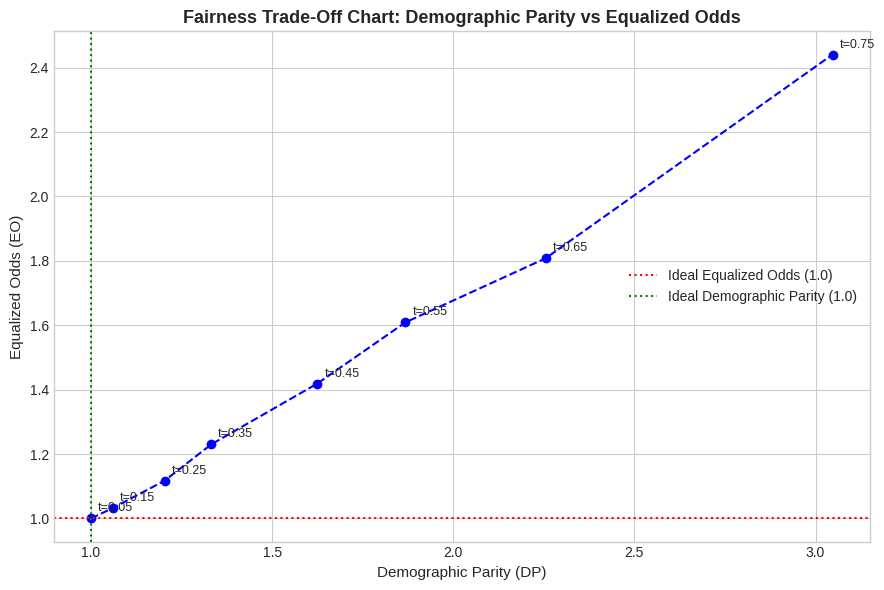

In [ ]:
# ==========================================
# CSET485: AI and Society - Assignment 1
# Dataset: COMPAS | Random Seed: 202
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
import statsmodels.api as sm

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(202)

# ------------------------------------------
# DATA LOADING & PREPROCESSING
# ------------------------------------------
print("--- LOADING AND PREPROCESSING DATA ---")
url = "https://github.com/propublica/compas-analysis/raw/master/compas-scores-two-years.csv"
df_raw = pd.read_csv(url)

# Standard COMPAS filtering (ProPublica methodology)
# Keep relevant columns and filter out invalid data
df = df_raw[['sex', 'age', 'age_cat', 'race', 'priors_count', 'c_charge_degree', 'decile_score', 'is_recid']].copy()
df = df.dropna()
df = df[(df['c_charge_degree'] != 'O')] # Filter out minor offenses/infractions

# Binary encoding
df['sex_binary'] = (df['sex'] == 'Female').astype(int) # 1=Female, 0=Male
df['charge_degree_binary'] = (df['c_charge_degree'] == 'F').astype(int) # 1=Felony, 0=Misdemeanor

# Features for modeling
feature_cols = ['age', 'priors_count', 'sex_binary', 'charge_degree_binary']
X = df[feature_cols]
y_decile = df['decile_score']  # For Model A (Linear)
y_recid = df['is_recid']       # For Model B (Logistic)

# Train-Test Split (70-30, random_state=202)
X_train, X_test, y_train_decile, y_test_decile, y_train_recid, y_test_recid = train_test_split(
    X, y_decile, y_recid, test_size=0.30, random_state=202
)

# Scaling features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

# Preserve demographic test metadata for fairness analysis
test_meta = df.loc[X_test.index, ['race', 'sex', 'age', 'priors_count']].copy()

print(f"Dataset Loaded Successfully! Train Shape: {X_train.shape}, Test Shape: {X_test.shape}\n")

# ==========================================
# PART 1: BUILD & MODEL COMPARISON
# ==========================================
print("==========================================")
print("PART 1: MODEL COMPARISON & MISMATCH ANALYSIS")
print("==========================================")

# Model A: Linear Regression predicting decile_score
model_a = LinearRegression()
model_a.fit(X_train_scaled, y_train_decile)
preds_a_continuous = model_a.predict(X_test_scaled)

# Model A Thresholding at Median Predicted Value
median_thresh_a = np.median(preds_a_continuous)
preds_a_binary = (preds_a_continuous >= median_thresh_a).astype(int)

# Model B: Logistic Regression predicting is_recid
model_b = LogisticRegression()
model_b.fit(X_train_scaled, y_train_recid)
preds_b_prob = model_b.predict_proba(X_test_scaled)[:, 1]

# Model B Thresholding at 0.5
preds_b_binary = (preds_b_prob >= 0.5).astype(int)

# Comparison & Confusion Matrix
cm_part1 = confusion_matrix(preds_a_binary, preds_b_binary)
mismatches = np.sum(preds_a_binary != preds_b_binary)
total_test = len(X_test)
mismatch_pct = (mismatches / total_test) * 100

print(f"Model A Median Predicted Threshold: {median_thresh_a:.4f}")
print("\nAgreement/Disagreement Confusion Matrix (Model A vs Model B):")
print(pd.DataFrame(cm_part1, columns=['Model B: Low', 'Model B: High'], index=['Model A: Low', 'Model A: High']))
print(f"\nMismatched Cases: {mismatches} out of {total_test} ({mismatch_pct:.2f}%)\n")

# ==========================================
# PART 2.1: SIMPSON'S PARADOX HUNT
# ==========================================
print("==========================================")
print("PART 2.1: SIMPSON'S PARADOX / SUBGROUP ANALYSIS")
print("==========================================")

# Add race info back to scaled dataset for subgroup analysis
X_train_sp = X_train_scaled.copy()
X_train_sp['race'] = df.loc[X_train.index, 'race']
y_sp = y_train_recid

# Split into African-American vs Caucasian subgroups
sub_aa = X_train_sp[X_train_sp['race'] == 'African-American'].drop(columns=['race'])
y_aa = y_sp[X_train_sp['race'] == 'African-American']

sub_cauc = X_train_sp[X_train_sp['race'] == 'Caucasian'].drop(columns=['race'])
y_cauc = y_sp[X_train_sp['race'] == 'Caucasian']

# Fit Logistic Regressions
log_full = LogisticRegression().fit(X_train_scaled, y_sp)
log_aa = LogisticRegression().fit(sub_aa, y_aa)
log_cauc = LogisticRegression().fit(sub_cauc, y_cauc)

coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Full Model Coef': log_full.coef_[0],
    'African-American Coef': log_aa.coef_[0],
    'Caucasian Coef': log_cauc.coef_[0]
})
print("Regression Coefficients Across Subgroups:")
print(coef_df.to_string(index=False))
print("\n")

# ==========================================
# PART 2.2: OMITTED-VARIABLE BIAS
# ==========================================
print("==========================================")
print("PART 2.2: OMITTED-VARIABLE BIAS")
print("==========================================")

# Drop 'priors_count' as the omitted confounder
X_train_reduced = X_train_scaled.drop(columns=['priors_count'])

# Fit full vs reduced
log_full_ovb = LogisticRegression().fit(X_train_scaled, y_train_recid)
log_red_ovb = LogisticRegression().fit(X_train_reduced, y_train_recid)

# Compare common features
common_cols = ['age', 'sex_binary', 'charge_degree_binary']
full_coefs = dict(zip(feature_cols, log_full_ovb.coef_[0]))
red_coefs = dict(zip(common_cols, log_red_ovb.coef_[0]))

ovb_table = []
for col in common_cols:
    b_full = full_coefs[col]
    b_red = red_coefs[col]
    pct_change = ((b_red - b_full) / abs(b_full)) * 100
    ovb_table.append({'Predictor': col, 'Full Model Coef': b_full, 'Reduced Model Coef': b_red, '% Shift': pct_change})

ovb_df = pd.DataFrame(ovb_table)
print("Omitted-Variable Bias Comparison (Dropped priors_count):")
print(ovb_df.to_string(index=False))
print("\n")

# ==========================================
# PART 2.3: ADVERSARIAL SUBSET CONSTRUCTION
# ==========================================
print("==========================================")
print("PART 2.3: ADVERSARIAL SUBSET ANALYSIS")
print("==========================================")

test_eval = pd.DataFrame({
    'actual': y_test_recid.values,
    'prob': preds_b_prob,
    'age': test_meta['age'].values,
    'priors_count': test_meta['priors_count'].values,
    'sex': test_meta['sex'].values,
    'race': test_meta['race'].values
})

# High-confidence errors
adv_subset = test_eval[
    ((test_eval['prob'] >= 0.75) & (test_eval['actual'] == 0)) |
    ((test_eval['prob'] <= 0.25) & (test_eval['actual'] == 1))
]

print(f"Total High-Confidence Wrong Predictions: {len(adv_subset)} out of {len(test_eval)} ({len(adv_subset)/len(test_eval)*100:.2f}%)")

# Sample up to 50
sample_size = min(50, len(adv_subset))
adv_sample = adv_subset.sample(n=sample_size, random_state=202) if len(adv_subset) > 0 else adv_subset

print(f"\nDemographics of 50-Row Adversarial Sample vs Full Test Set:")
print(f"Adversarial Mean Priors: {adv_sample['priors_count'].mean():.2f} | Full Test Mean Priors: {test_eval['priors_count'].mean():.2f}")
print(f"Adversarial Mean Age: {adv_sample['age'].mean():.2f} | Full Test Mean Age: {test_eval['age'].mean():.2f}")
print("\nAdversarial Sample Race Breakdown (%):")
print((adv_sample['race'].value_counts(normalize=True) * 100).round(2).to_string())
print("\n")

# ==========================================
# PART 2.4: FAIRNESS TRADE-OFF ANALYSIS
# ==========================================
print("==========================================")
print("PART 2.4: FAIRNESS SWEEP & TRADE-OFF CHART")
print("==========================================")

test_fairness = pd.DataFrame({
    'y_true': y_test_recid.values,
    'prob': preds_b_prob,
    'race': test_meta['race'].values
})

# Keep two primary groups: African-American vs Caucasian
test_fairness = test_fairness[test_fairness['race'].isin(['African-American', 'Caucasian'])].copy()

thresholds = np.arange(0.05, 0.96, 0.1)
metrics_list = []

for t in thresholds:
    test_fairness['y_pred'] = (test_fairness['prob'] >= t).astype(int)

    # Group A: African-American, Group B: Caucasian
    gA = test_fairness[test_fairness['race'] == 'African-American']
    gB = test_fairness[test_fairness['race'] == 'Caucasian']

    # Demographic Parity: P(Yhat=1|A) / P(Yhat=1|B)
    p_hat_A = gA['y_pred'].mean()
    p_hat_B = gB['y_pred'].mean()
    dp = p_hat_A / p_hat_B if p_hat_B > 0 else np.nan

    # TPR & FPR for Equalized Odds
    tpr_A = (gA[(gA['y_true']==1)]['y_pred'] == 1).mean() if len(gA[gA['y_true']==1]) > 0 else 0
    tpr_B = (gB[(gB['y_true']==1)]['y_pred'] == 1).mean() if len(gB[gB['y_true']==1]) > 0 else 0

    fpr_A = (gA[(gA['y_true']==0)]['y_pred'] == 1).mean() if len(gA[gA['y_true']==0]) > 0 else 0
    fpr_B = (gB[(gB['y_true']==0)]['y_pred'] == 1).mean() if len(gB[gB['y_true']==0]) > 0 else 0

    ratio_tpr = tpr_A / tpr_B if tpr_B > 0 else np.nan
    ratio_fpr = fpr_A / fpr_B if fpr_B > 0 else np.nan
    eo = min(ratio_tpr, ratio_fpr) if not np.isnan(ratio_tpr) and not np.isnan(ratio_fpr) else np.nan

    # Predictive Parity: P(Y=1|Yhat=1, A) / P(Y=1|Yhat=1, B)
    ppv_A = (gA[gA['y_pred']==1]['y_true'] == 1).mean() if len(gA[gA['y_pred']==1]) > 0 else np.nan
    ppv_B = (gB[gB['y_pred']==1]['y_true'] == 1).mean() if len(gB[gB['y_pred']==1]) > 0 else np.nan
    pp = ppv_A / ppv_B if ppv_B > 0 and not np.isnan(ppv_B) else np.nan

    metrics_list.append({
        'Threshold': round(t, 2),
        'Demographic Parity (DP)': round(dp, 3),
        'Equalized Odds (EO)': round(eo, 3),
        'Predictive Parity (PP)': round(pp, 3)
    })

fairness_df = pd.DataFrame(metrics_list)
print("Fairness Metrics Across Decision Thresholds Sweep:")
print(fairness_df.to_string(index=False))

# Plot Trade-off Chart
plt.figure(figsize=(9, 6))
plt.plot(fairness_df['Demographic Parity (DP)'], fairness_df['Equalized Odds (EO)'], marker='o', color='b', linestyle='--')

for _, row in fairness_df.iterrows():
    plt.annotate(f"t={row['Threshold']}", (row['Demographic Parity (DP)'], row['Equalized Odds (EO)']),
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=9)

plt.title("Fairness Trade-Off Chart: Demographic Parity vs Equalized Odds", fontsize=13, fontweight='bold')
plt.xlabel("Demographic Parity (DP)", fontsize=11)
plt.ylabel("Equalized Odds (EO)", fontsize=11)
plt.axhline(1.0, color='red', linestyle=':', label='Ideal Equalized Odds (1.0)')
plt.axvline(1.0, color='green', linestyle=':', label='Ideal Demographic Parity (1.0)')
plt.legend()
plt.tight_layout()
plt.show()